In [2]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, avg_tail

import cariaco_obs as co
import parscan_utils as pu
import parscan_plots as pp
for m in (co, pu, pp):                # pick up edits without a kernel restart
    importlib.reload(m)

In [3]:
import baseline_r0_setups as brs
import parscan_utils as pu
import parscan_utils_extended as pue
import cariaco_obs as co

# obs side
_, _, _, monthly_df, forcing = co.load_cariaco_targets(regime='upwelling',
                                                       months='hplc', agg='median',
                                                       include_temperature=True)
obs_refs = pue.build_obs_refs(monthly_df)

# model side — single point at default forcing
out = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                          scan_params={}, fixed_overrides=forcing)
print(out)  # full output, should have Growth__uptake_value + DetritusSink__sinking_value

<xarray.Dataset> Size: 146MB
Dimensions:                                 (time: 5000, phyto: 40, zoo: 40,
                                             full: 80, clock: 2)
Coordinates:
  * time                                    (time) float64 40kB 0.0 ... 4.999...
  * phyto                                   (phyto) float64 320B 0.2 ... 200.0
  * zoo                                     (zoo) float64 320B 2.0 ... 2e+03
  * clock                                   (clock) float64 16B 0.0 1.0
Dimensions without coordinates: full
Data variables: (12/104)
    Core__solver_kwargs                     <U49 196B '{"method": "RK45", "at...
    Core__solver_type                       <U9 36B 'solve_ivp'
    DetritusRemin__detritus                 <U1 4B 'D'
    DetritusRemin__k_remin                  float64 8B 0.1
    DetritusRemin__nutrient                 <U1 4B 'N'
    DetritusRemin__remineralization_value   (time) float64 40kB 0.0002363 ......
    ...                                      ...
 

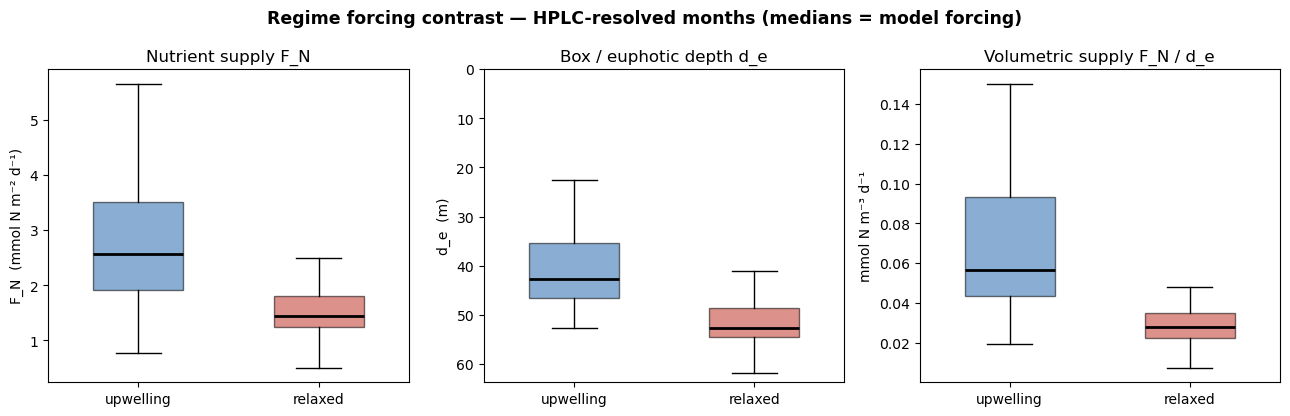

upwelling   n=31   F_N= 2.58   d_e= 42.8   T= 23.0°C   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   T= 25.4°C   F_N/d_e=0.0275


In [7]:
# ── Cell 4 — regime forcing (upwelling vs relaxed, HPLC months, +temperature) ─
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median', include_temperature=True)
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"T={f.get('Temperature__value', float('nan')):5.1f}°C   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

In [4]:
import xarray as xr
import numpy as np
# (the analysis notebook needs the same parscan_utils_extended + cariaco_obs imports
# to compute err and rebuild obs_refs)
import parscan_utils_extended as pue
import cariaco_obs as co

# Load both regimes (relaxed will be the partial file once it starts)
ds_up = xr.open_dataset('night_scan_upwelling.nc').load()
ds_up.close()

# Build obs_refs for the regime you're analysing
_, _, _, monthly_df_up, _ = co.load_cariaco_targets(
    regime='upwelling', months='hplc', agg='median', include_temperature=True)
obs_refs_up = pue.build_obs_refs(monthly_df_up)

# Compute err_eq + err_zw on the loaded snapshot
METRIC_KEYS = ['mcs', 'P_pico', 'P_nano', 'P_micro', 'sumP',
               'Z_gt200', 'Z_gt500', 'sumZ', 'N', 'D', 'PP', 'Export']
metrics = {k: ds_up[k].values for k in METRIC_KEYS}
ds_up['err_eq'] = (('sample',), pue.joint_error(metrics, obs_refs_up))
ds_up['err_zw'] = (('sample',), pue.joint_error(metrics, obs_refs_up,
                                                  weights={**{t: 1.0 for t in pue.DEFAULT_TARGETS},
                                                           'Z_gt200': 2.0, 'Z_gt500': 2.0}))

# Top fits
top10 = ds_up.sortby('err_zw').isel(sample=slice(None, 10))
cols = ['Grazing__KsZ', 'Grazing__sigma_log', 'GrazingRouter__gge',
        'DetritusRemin__k_remin', 'DetritusSink__w_sink',
        'ZooQuadMortality__rate', 'err_zw', 'err_eq',
        'mcs', 'Z_gt200', 'Z_gt500', 'P_pico', 'P_nano', 'P_micro']
(top10[cols].to_dataframe())

,Grazing__KsZ,Grazing__sigma_log,GrazingRouter__gge,DetritusRemin__k_remin,DetritusSink__w_sink,ZooQuadMortality__rate,err_zw,err_eq,mcs,Z_gt200,Z_gt500,P_pico,P_nano,P_micro
sample,,,,,,,,,,,,,,
2802,0.100000,0.144444,0.2,0.3,2.5,0.175,0.087001,0.095552,4.529655,0.087158,0.047447,0.253730,0.117240,0.175442
2918,0.138889,0.277778,0.2,0.3,2.5,0.300,0.119844,0.125278,4.661878,0.073224,0.046778,0.227536,0.106626,0.162573
2917,0.138889,0.255556,0.2,0.3,2.5,0.300,0.123295,0.133458,5.723363,0.075781,0.054574,0.219492,0.104069,0.197759
2829,0.177778,0.300000,0.2,0.3,2.5,0.175,0.138822,0.140772,4.222123,0.094671,0.057228,0.243657,0.116701,0.154219
2803,0.100000,0.166667,0.2,0.3,2.5,0.175,0.138966,0.151496,4.090599,0.094278,0.050227,0.240373,0.110354,0.147019
2828,0.177778,0.277778,0.2,0.3,2.5,0.175,0.141613,0.149183,4.290503,0.072475,0.045640,0.262250,0.104788,0.172275
2816,0.138889,0.233333,0.2,0.3,2.5,0.175,0.145312,0.166215,3.884981,0.083635,0.047735,0.252826,0.105458,0.146786
2801,0.100000,0.122222,0.2,0.3,2.5,0.175,0.147441,0.148667,5.136094,0.080043,0.040512,0.273507,0.118099,0.219313
2916,0.138889,0.233333,0.2,0.3,2.5,0.300,0.148957,0.143115,5.344770,0.070929,0.041528,0.243822,0.107614,0.204147


In [5]:
print(top10[cols].to_dataframe())

        Grazing__KsZ  Grazing__sigma_log  GrazingRouter__gge  \
sample                                                         
2802        0.100000            0.144444                 0.2   
2918        0.138889            0.277778                 0.2   
2917        0.138889            0.255556                 0.2   
2829        0.177778            0.300000                 0.2   
2803        0.100000            0.166667                 0.2   
2828        0.177778            0.277778                 0.2   
2816        0.138889            0.233333                 0.2   
2801        0.100000            0.122222                 0.2   
2916        0.138889            0.233333                 0.2   
2904        0.100000            0.188889                 0.2   

        DetritusRemin__k_remin  DetritusSink__w_sink  ZooQuadMortality__rate  \
sample                                                                         
2802                       0.3                   2.5                   

In [8]:
# ── Cell — Test best-fit parameters from night scan at both regimes ─────────
# Best fit from upwelling scan (sample 2802, err_zw=0.087):
#   K_sZ=0.10, σ=0.144, GGE=0.20, k_remin=0.30, w_sink=2.5, m_Z=0.175
# Single-point comparison: baseline (defaults) vs best-fit vs obs per regime.
TAIL = 1000

BEST_PARAMS = {
    'Grazing__KsZ':            0.10,
    'Grazing__sigma_log':      0.144,
    'GrazingRouter__gge':      0.20,
    'DetritusRemin__k_remin':  0.30,
    'DetritusSink__w_sink':    2.5,
    'ZooQuadMortality__rate':  0.175,
}

def _extract_point_metrics(out, d_e):
    T = out.isel(time=slice(-TAIL, None))
    P = T['Phytoplankton__biomass'].mean('time').values
    Z = T['Zooplankton__biomass'].mean('time').values
    W = pue.compute_sieburth_weights(brs.phyto_esd)
    bins = P @ W.T
    frac = bins / max(bins.sum(), 1e-30)
    return dict(
        mcs    = float(10.0 ** (frac @ np.log10(pue.CARIACO_PHYTO_BIN_GEOMEANS))),
        P_pico = float(bins[0]), P_nano = float(bins[1]), P_micro = float(bins[2]),
        sumP   = float(P.sum()),
        Z_gt200= float(Z[brs.zoo_esd > 200.0].sum()),
        Z_gt500= float(Z[brs.zoo_esd > 500.0].sum()),
        sumZ   = float(Z.sum()),
        N      = float(T['Nutrient__value'].mean('time')),
        D      = float(T['Detritus__value'].mean('time')),
        PP     = float(T['Growth__uptake_value'].mean('time').sum()),
        Export = float(T['DetritusSink__sinking_value'].mean('time')) * d_e,
    )

f3 = lambda v: f"{v:7.3f}" if np.isfinite(v) else f"{'-':>7}"
f4 = lambda v: f"{v:7.4f}" if np.isfinite(v) else f"{'-':>7}"
fm = lambda v: f"{v:6.2f}" if np.isfinite(v) else f"{'-':>6}"

def _row(label, m):
    return (f"{label:>10} {fm(m['mcs'])} {f3(m['P_pico'])} {f3(m['P_nano'])} "
            f"{f3(m['P_micro'])} {f3(m['sumP'])} {f4(m['Z_gt200'])} "
            f"{f4(m['Z_gt500'])} {f3(m['sumZ'])} {f3(m['N'])} {f3(m['D'])} "
            f"{f3(m['PP'])} {f3(m['Export'])}")

for r in regimes:
    d_e = float(targets[r]['forcing']['Inflow__de'])
    obs = pue.build_obs_refs(targets[r]['monthly_df'])

    out_base = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                                    scan_params={},
                                    fixed_overrides=targets[r]['forcing'])
    out_best = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                                    scan_params={},
                                    fixed_overrides={**targets[r]['forcing'],
                                                     **BEST_PARAMS})

    m_base = _extract_point_metrics(out_base, d_e)
    m_best = _extract_point_metrics(out_best, d_e)

    o_metrics = dict(
        mcs=obs['mcs'], P_pico=obs['P_pico'], P_nano=obs['P_nano'],
        P_micro=obs['P_micro'], sumP=obs['sumP'],
        Z_gt200=obs['Z_gt200'], Z_gt500=obs['Z_gt500'],
        sumZ=np.nan, N=obs['N'], D=np.nan, PP=obs['PP'], Export=obs['Export'],
    )

    print(f"\n=== Best-fit cross-regime test — {r.upper()}  "
          f"(F_N={targets[r]['forcing']['Inflow__FN']:.2f}, "
          f"d_e={d_e:.1f}) ===")
    print(f"{'config':>10} {'mcs':>6} {'Pico':>7} {'Nano':>7} {'Micro':>7} "
          f"{'ΣP':>7} {'Z>200':>7} {'Z>500':>7} {'ΣZ':>7} "
          f"{'N':>7} {'D':>7} {'PP':>7} {'Exp':>7}")
    print(_row('baseline',  m_base))
    print(_row('+best_fit', m_best))
    print(_row('obs',       o_metrics))


=== Best-fit cross-regime test — UPWELLING  (F_N=2.58, d_e=42.8) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
  baseline   5.11   0.237   0.081   0.191   0.509  0.0141  0.0024   0.211   0.084   0.497   0.140   2.484
 +best_fit   4.55   0.254   0.116   0.177   0.547  0.0864  0.0473   0.261   0.754   0.929   0.442   2.324
       obs   4.84   0.224   0.137   0.192   0.583  0.0835  0.0506       -   2.006       -   0.295   3.192

=== Best-fit cross-regime test — RELAXED  (F_N=1.45, d_e=52.7) ===
    config    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
  baseline   2.94   0.171   0.074   0.068   0.313  0.0027  0.0000   0.136   0.046   0.280   0.070   1.401
 +best_fit   5.28   0.174   0.060   0.145   0.378  0.0395  0.0197   0.175   0.315   0.523   0.240   1.309
       obs   2.01   0.246   0.111   0.046   0.436  0.0479  0.0233       -   0.654       -   0.181   1.398


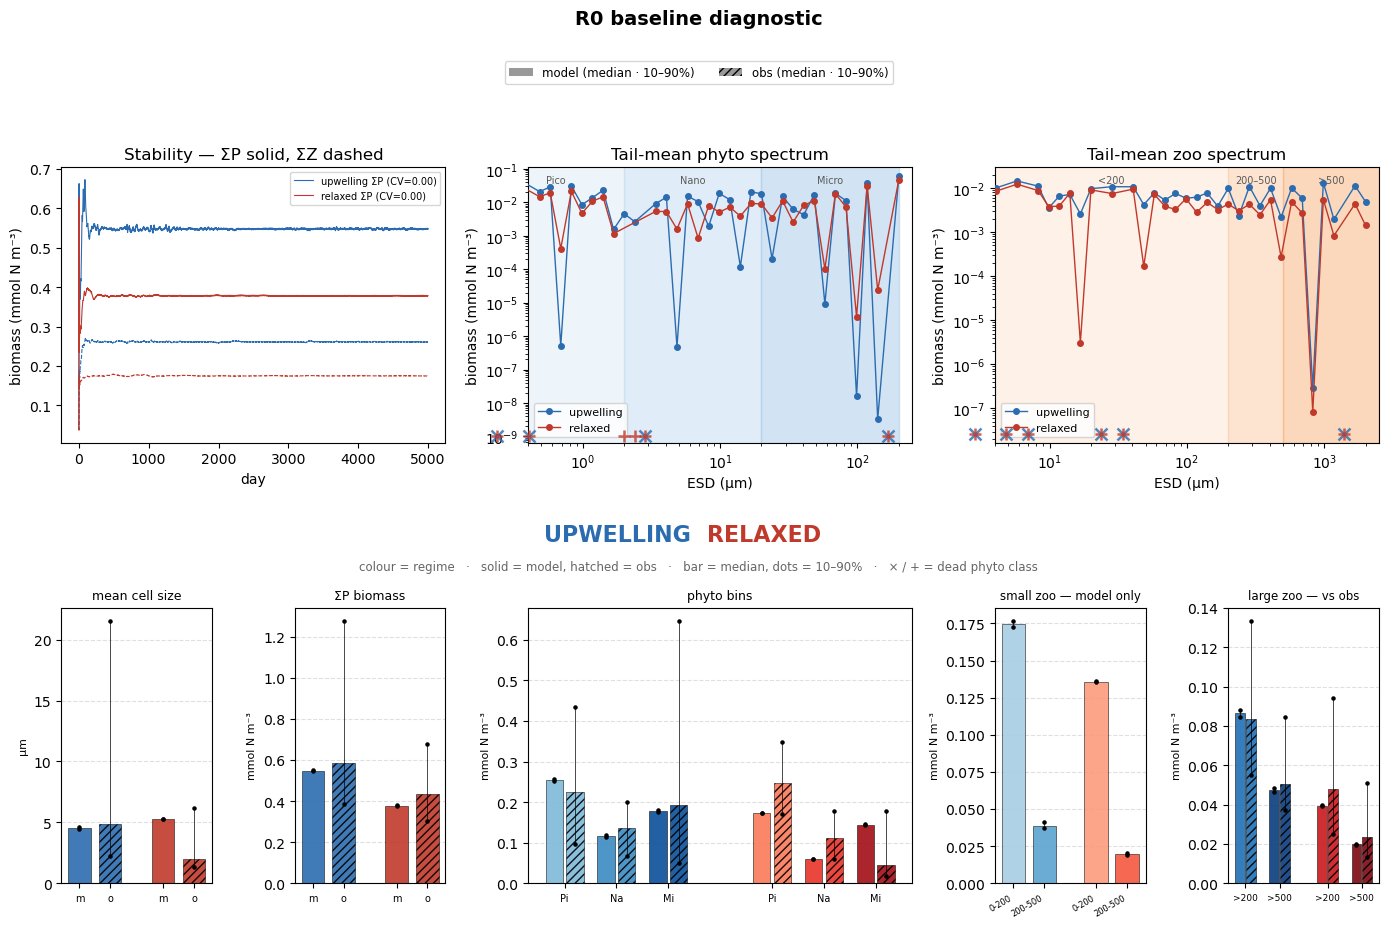

In [9]:
# ── Plot best-fit vs obs using pp.plot_regime_diagnostic ────────────────────
model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    overrides = {**targets[r]['forcing'], **BEST_PARAMS}
    out_best  = pu.run_single_point(brs.model_baseline, brs.setup_baseline,
                                     scan_params={}, fixed_overrides=overrides)
    model_by_regime[r] = pu.process_regime_run(out_best, brs.phyto_esd, brs.zoo_esd,
                                                bin_defs, tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                brs.phyto_esd, brs.zoo_esd, regimes=regimes)
plt.show()

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'setup_baseline_slim' from 'baseline_r0_setups' with postprocess 'avg_tail'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'baseline_r0_setups' over 25 points using 8 workers...


/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=74.9 on P[2] = -1.02e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=243.9 on P[10] = -1.35e-06. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)
/Users/aoop/Documents/GitHub/Research/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=188.6 on P[0] = -1.43. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'

1D Scan complete. Time taken: 748.69096 seconds.

=== F_N scan at best-fit  (d_e=42.8, T=23.0°C) ===
   F_N    mcs    Pico    Nano   Micro      ΣP   Z>200   Z>500      ΣZ       N       D      PP     Exp
 0.500   6.09   0.127   0.047   0.122   0.296  0.0085  0.0020   0.100   0.105   0.185   0.086   0.463
 0.979   6.69   0.164   0.057   0.174   0.395  0.0242  0.0108   0.149   0.211   0.359   0.169   0.896
 1.458   5.73   0.194   0.072   0.175   0.441  0.0425  0.0216   0.188   0.346   0.530   0.250   1.325
 1.938   5.07   0.221   0.090   0.175   0.486  0.0617  0.0320   0.221   0.500   0.702   0.333   1.754
 2.417   4.65   0.246   0.109   0.176   0.532  0.0799  0.0433   0.251   0.683   0.872   0.414   2.180
 2.896   4.40   0.269   0.130   0.179   0.578  0.0999  0.0549   0.280   0.903   1.041   0.495   2.603
 3.375   4.23   0.290   0.151   0.182   0.624  0.1188  0.0685   0.308   1.169   1.208   0.575   3.021
 3.854   4.12   0.309   0.176   0.185   0.670  0.1394  0.0824   0.334   1.493   1.3

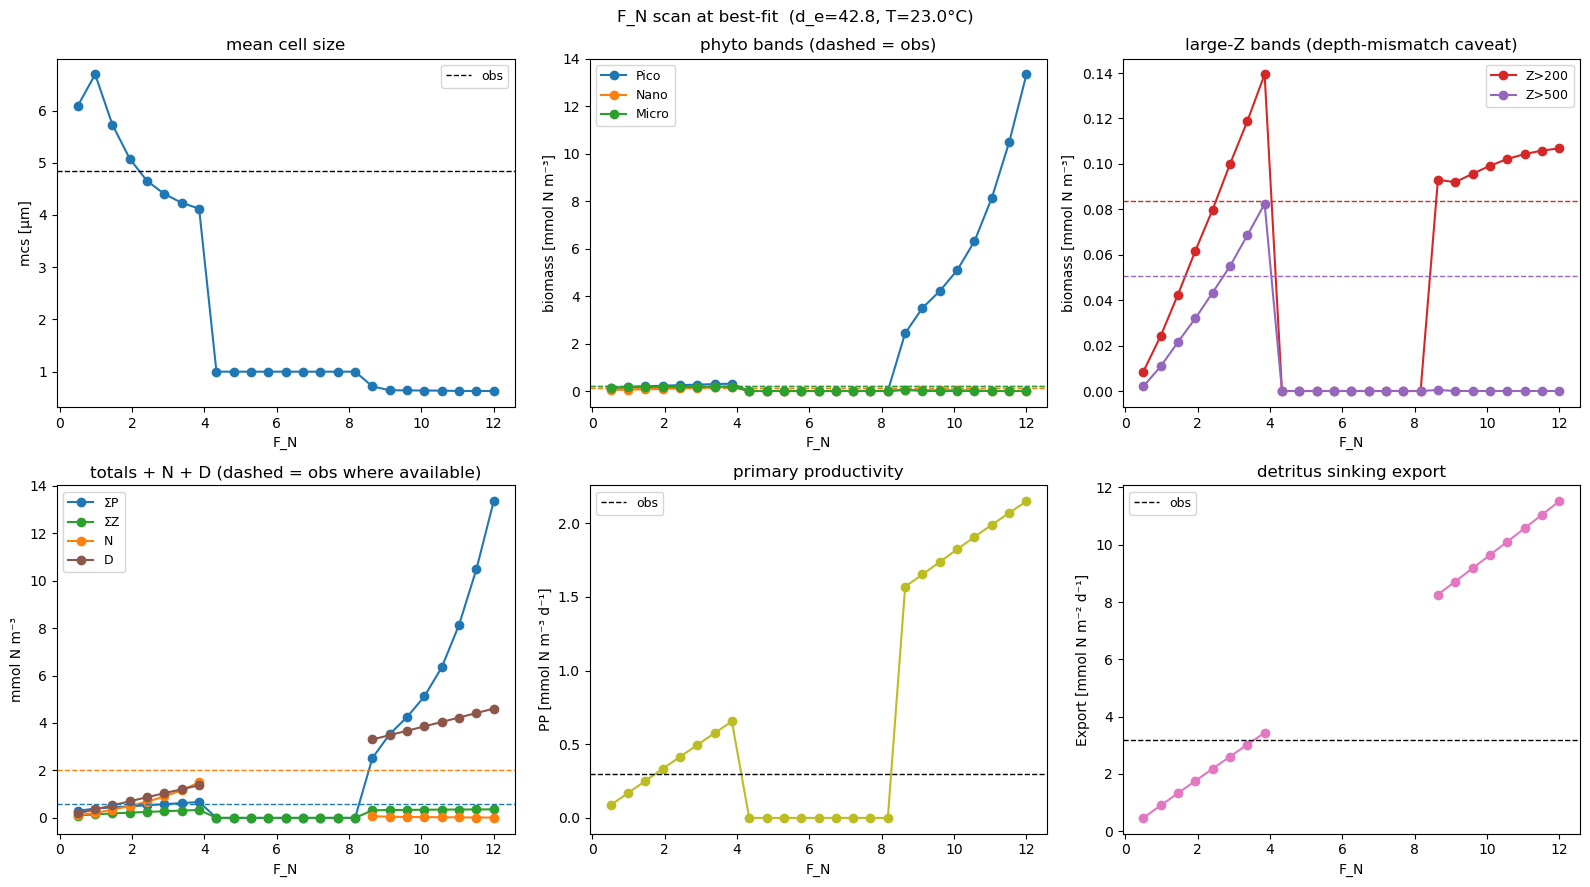

In [10]:
# ── Cell — F_N scan at best-fit parameter set ───────────────────────────────
# Scans Inflow__FN at the night-scan best-fit parameter set with d_e + T from
# the upwelling regime (where the params were fitted). Single scan to see the
# spectrum dynamics under varying nutrient supply.
PARAM       = 'Inflow__FN'
AXIS_LABEL  = 'F_N'
AXIS_VALUES = np.linspace(0.5, 12.0, 25)
TAIL_AVG    = 1000

ENV_REGIME = 'upwelling'   # use this regime's d_e + T as the environment
env_forcing = targets[ENV_REGIME]['forcing']
fixed_overrides = {
    'Inflow__de':         env_forcing['Inflow__de'],
    'Temperature__value': env_forcing['Temperature__value'],
    **BEST_PARAMS,
}

obs_refs = pue.build_obs_refs(targets[ENV_REGIME]['monthly_df'])

scan_FN = run_xso_parscan(
    model_file_name='baseline_r0_setups',
    model_name='model_baseline',
    model_setup_name='setup_baseline_slim',
    param_name=PARAM,
    param_values=AXIS_VALUES,
    fixed_overrides=fixed_overrides,
    postprocess_name='avg_tail',
    postprocess_kwargs={'avg_window': TAIL_AVG},
    processes=8,
)

metrics_FN = pue.extract_scan_metrics_1d(scan_FN, PARAM, env_forcing)

header = (f"F_N scan at best-fit  "
          f"(d_e={env_forcing['Inflow__de']:.1f}, "
          f"T={env_forcing['Temperature__value']:.1f}°C)")
pue.print_scan_table_1d(metrics_FN, obs_refs, header, axis_label=AXIS_LABEL)
pue.plot_scan_panels_1d(metrics_FN, obs_refs, header, axis_label=AXIS_LABEL)
plt.show()